In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent
SRC_PATH = PROJECT_ROOT/"src"
sys.path.append(str(SRC_PATH))

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from model import FinancialSentimentModel
from data_module import DatasetModule
from config import DEVICE, MODEL_SAVE_DIR, MODEL_SAVE_NAME

c:\Users\ASUS\Desktop\sentiment-analysis\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Load Model

In [3]:
model = FinancialSentimentModel().get_model()
checkpoint = torch.load (MODEL_SAVE_DIR/MODEL_SAVE_NAME, map_location=DEVICE)
model.load_state_dict (checkpoint['model_state_dict'])
model.to(DEVICE)
model.eval()

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 13293.62it/s]


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,),

### Load Test Loader

In [4]:
data_module = DatasetModule(dataset_path=Path("../data/tokenized"))
data_module.load_data()
data_module.setup()
test_loader = data_module.test_dataloader()        

### Prediction

In [5]:
predictions = []
labels = []
confidences = []

In [6]:
with torch.no_grad():
    for batch in test_loader:
        batch = {key: value.to(DEVICE) for key, value in batch.items()}
        outputs = model (**batch)
        logits = outputs.logits
        probs = torch.softmax (logits, dim=1)
        confidence, preds = torch.max (probs, dim=1)

        predictions.extend (preds.cpu().numpy())
        labels.extend (batch['labels'].cpu().numpy())
        confidences.extend (confidence.cpu().numpy())
        

In [7]:
results = pd.DataFrame (
    {
        "true_label": labels,
        "predictions": predictions,
        "confidence": confidences
    }
)
results.head()

,true_label,predictions,confidence
0,2,2,0.991589
1,2,2,0.990175
2,1,1,0.830299
3,2,2,0.990530
4,2,2,0.988224


### Classification Report

In [14]:
print (classification_report (results["true_label"], results["predictions"]))

              precision    recall  f1-score   support

           0       0.82      0.69      0.75        45
           1       0.81      0.92      0.86        86
           2       1.00      0.98      0.99       208

    accuracy                           0.92       339
   macro avg       0.87      0.86      0.86       339
weighted avg       0.93      0.92      0.92       339



### Confusion Matrix

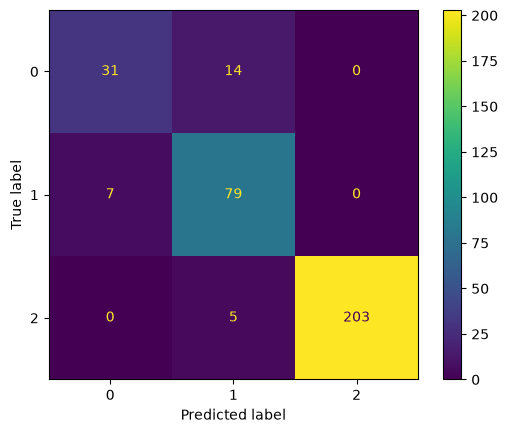

In [15]:
cm = confusion_matrix (results.true_label, results.predictions)
disp = ConfusionMatrixDisplay (confusion_matrix=cm)
disp.plot()
plt.show()

### Wrong Predictions

In [16]:
errors = results [results.true_label != results.predictions]
errors.head(20)

,true_label,predictions,confidence
34,0,1,0.885226
38,1,0,0.550068
69,0,1,0.628252
75,0,1,0.647483
83,2,1,0.718606
106,0,1,0.712680
108,0,1,0.505852
111,0,1,0.626977
125,1,0,0.603714
127,2,1,0.855736


### Confidence Distribution

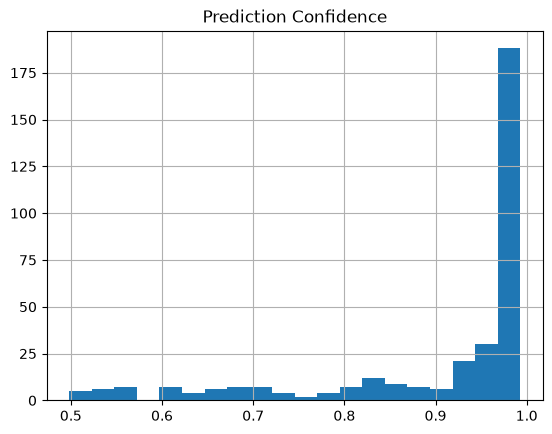

In [17]:
results.confidence.hist (bins=20)
plt.title ("Prediction Confidence")
plt.show ()

In [18]:
high_conf_errors = errors[errors.confidence > 0.90]
high_conf_errors

,true_label,predictions,confidence
148,2,1,0.910289
149,2,1,0.942859
251,0,1,0.954490


### Accuracy

In [19]:
pd.crosstab (results.true_label, results.predictions, normalize="index")

predictions,0,1,2
true_label,,,
0,0.688889,0.311111,0.000000
1,0.081395,0.918605,0.000000
2,0.000000,0.024038,0.975962


### Highest-Confidence Errors

In [21]:
errors.sort_values ("confidence", ascending=False).head(20)

,true_label,predictions,confidence
251,0,1,0.954490
149,2,1,0.942859
148,2,1,0.910289
34,0,1,0.885226
127,2,1,0.855736
238,1,0,0.753190
327,0,1,0.743128
183,1,0,0.742894
83,2,1,0.718606
106,0,1,0.712680


### Final Error Analysis Conclusion
The error analysis shows that the Transformer model achieved a strong performance in financial sentiment classification. The model performed exceptionally well in identifying neutral financial statements; however, it still faces challenges in distinguishing between positive financial information and actual positive sentiment.
Most errors occurred when positive financial indicators, such as increased revenue, sales growth, and improved performance, appeared in neutral reports or negative contexts. The model also showed limitations in detecting implicit negative meanings and understanding sentences with contrastive structures.
High-confidence errors revealed that the model suffers from confidence calibration issues, where it may assign high confidence even when making incorrect predictions.
Overall, incorporating financial-domain knowledge through approaches such as FinBERT-based models, larger and balanced training datasets, and hard-example training could improve the model’s understanding of financial language and further reduce classification errors.
